<table><tr><th><div style='padding:15px;color:#030aa7;font-size:240%;text-align:center;font-style:italic;font-weight:bold;font-family:Georgia,serif'>Piloter la performance — e‑Brasil</div></th></tr></table>

<div style='text-align:center'><img src='https://raw.githubusercontent.com/rbizoi/dockerBigDataBI/refs/heads/master/images/bi/famille_6.png' width='1024'></div>
<div style='text-align:center'><img src='https://raw.githubusercontent.com/rbizoi/dockerBigDataBI/refs/heads/master/images/bi/famille_6_description.png' width='1024'></div>

<div style='padding:15px;color:#030aa7;font-family:Georgia,serif'>Atelier BI · Famille 06 · 6 graphiques × 3 bibliothèques</div>

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Introduction</div></b>

Les tables locales constituent la source ; aucune base de démonstration ne les remplace. Les articles sont agrégés au niveau commande avant jointure. Les commandes sans article ou sans livraison restent manquantes pour les mesures concernées. Les délais sont recalculés : les colonnes de durée préexistantes ne sont pas présumées documentées. L’unité monétaire BRL est une hypothèse de contexte ; les graphiques indiquent « montant source ».

**Objectif :** construire les six représentations de cette famille sur les données réelles, comparer les encodages et interpréter leurs limites. Les trois variantes utilisent exactement la même table préparée. Les constructions composites Seaborn sont signalées : cette bibliothèque ne propose pas tous les types nativement.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Sommaire</div></b>

1. Carte KPI
2. Bullet chart
3. Barres divergentes
4. Cascade ou waterfall
5. Pareto
6. Entonnoir ou funnel

Exécution : ouvrir le dossier extrait, sélectionner un noyau Python avec les dépendances de `requirements.txt`, puis **Redémarrer le noyau et tout exécuter**. Les résultats sont déjà enregistrés. Adapter `config_donnees.json` si les fichiers changent de place.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Import des bibliothèques</div></b>

In [1]:
NOM_PROJET = '06_ecommerce'
from pathlib import Path
import os, json, warnings
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle, Polygon, Wedge
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde
import networkx as nx
import squarify

get_ipython().run_line_magic('matplotlib', 'inline')
SEED = 42
palette = ["#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973",
           "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#c071fe"]
sns.set_theme(style='darkgrid', palette=palette, context='notebook', font_scale=1.05)
plt.rcParams.update({'figure.figsize': (11, 5), 'figure.dpi': 110})
pio.templates['bi_modele'] = pio.templates['plotly_white']
pio.templates['bi_modele'].layout.colorway = palette
pio.templates.default = 'bi_modele'
pio.renderers.default = 'plotly_mimetype'
px.defaults.color_discrete_sequence = palette
EXPORTER = False  # True : PNG statiques et HTML interactifs dans repertoire.images.
repertoireImages = Path('repertoire.images') / NOM_PROJET

def sauvegarderImage(nom, fig=None):
    fig = fig if fig is not None else plt.gcf()
    if EXPORTER:
        repertoireImages.mkdir(parents=True, exist_ok=True)
        fig.savefig(repertoireImages / (nom + '.png'), dpi=180, bbox_inches='tight')

def terminer(ax, titre, xlabel=None, ylabel=None):
    ax.set_title(titre, loc='left', fontweight='bold', pad=14)
    if xlabel is not None: ax.set_xlabel(xlabel)
    if ylabel is not None: ax.set_ylabel(ylabel)
    ax.figure.tight_layout()
    sauvegarderImage(ID_GRAPHIQUE + '_' + BIBLIOTHEQUE, ax.figure)
    plt.show()
    plt.close(ax.figure)

def montrer_plotly(fig, titre):
    fig.update_layout(title=titre, width=1000, height=520,
                      margin=dict(l=70, r=45, t=90, b=75),
                      font=dict(family='Arial', size=13))
    if EXPORTER:
        repertoireImages.mkdir(parents=True, exist_ok=True)
        fig.write_html(repertoireImages / (ID_GRAPHIQUE + '_plotly.html'), include_plotlyjs=True)
    fig.show()

def creer_axes(seaborn=False, **kwargs):
    # Matplotlib reste autonome ; Seaborn garde le style et la palette du modèle.
    plt.style.use('default')
    if seaborn: sns.set_theme(style='darkgrid', palette=palette, context='notebook')
    return plt.subplots(figsize=(11, 5), **kwargs)

print('Versions :', 'pandas', pd.__version__, 'seaborn', sns.__version__,
      'plotly', __import__('plotly').__version__, 'matplotlib', __import__('matplotlib').__version__)

Versions : pandas 2.3.3 seaborn 0.13.2 plotly 7.1.0 matplotlib 3.10.9


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Outils du document</div></b>

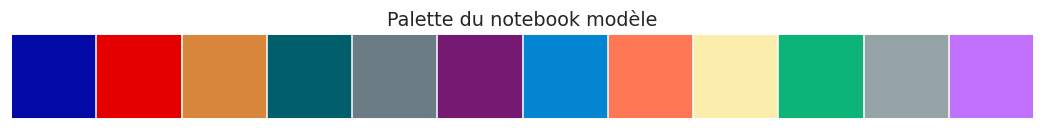

In [2]:
sns.palplot(sns.color_palette(palette))
plt.title('Palette du notebook modèle')
plt.show()
plt.close('all')

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Lecture des données</div></b>

<table><tr><th style="background:#053061;color:white">Colonne</th><th style="background:#053061;color:white">Description</th></tr><tr><td>orders.order_id</td><td>Une ligne par commande</td></tr><tr><td>items.price / freight_value</td><td>Prix article et frais de port ; montants supposés BRL pour ce jeu brésilien</td></tr><tr><td>customers.state</td><td>État du client</td></tr><tr><td>purchase_timestamp / delivered_customer</td><td>Dates d’achat et de livraison</td></tr><tr><td>delai_jours</td><td>Durée achat → livraison calculée à partir des horodatages</td></tr><tr><td>retard_jours</td><td>Écart entre jour livré et jour estimé ; positif = retard</td></tr></table>

In [3]:
CHEMINS = {'meteo': '/opt/spark/data/meteo.gzip', 'web': '/opt/spark/data/Web.Server.Access10.gzip', 'ecommerce': '/opt/spark/notebooks/ecommerce'}
configuration = Path('config_donnees.json')
if configuration.exists():
    CHEMINS.update(json.loads(configuration.read_text(encoding='utf-8')))
for cle in CHEMINS:
    CHEMINS[cle] = os.environ.get('BI_' + cle.upper(), CHEMINS[cle])
assert Path(CHEMINS['ecommerce']).exists(), 'Vérifier config_donnees.json'

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Contrôle des données et préparation</div></b>

In [4]:
racine = Path(CHEMINS['ecommerce'])
orders = pd.read_parquet(racine / 'orders.parquet')
items = pd.read_parquet(racine / 'items.parquet')
customers = pd.read_parquet(racine / 'customers.parquet')
assert orders['order_id'].is_unique, 'order_id doit être unique dans orders'
assert customers['customer_id'].is_unique, 'customer_id doit être unique'
assert not items.duplicated(['order_id','order_item_id']).any(), 'Doublons d’articles'
# Agréger les articles AVANT la jointure empêche de multiplier les commandes.
montants = items.groupby('order_id').agg(montant_articles=('price','sum'),
                                        frais_port=('freight_value','sum'),
                                        nb_articles=('order_item_id','size')).reset_index()
donnees = orders.merge(montants, on='order_id', how='left', validate='one_to_one')
donnees = donnees.merge(customers[['customer_id','state']], on='customer_id',
                        how='left', validate='many_to_one')
for col in ['purchase_timestamp','approved_at','delivered_carrier','delivered_customer','estimated_delivery']:
    donnees[col] = pd.to_datetime(donnees[col], errors='coerce')
donnees['total_commande'] = donnees['montant_articles'] + donnees['frais_port']
donnees['delai_jours'] = (donnees['delivered_customer'] - donnees['purchase_timestamp']).dt.total_seconds()/86400
print('Délais négatifs masqués :', donnees['delai_jours'].lt(0).sum())
donnees.loc[donnees['delai_jours'].lt(0), 'delai_jours'] = np.nan
# La promesse est une date : comparer les jours calendaires et non minuit à l’heure réelle.
donnees['retard_jours'] = (donnees['delivered_customer'].dt.normalize() - donnees['estimated_delivery'].dt.normalize()).dt.days
donnees['state'] = donnees['state'].fillna('Inconnu')
print('Commandes :', len(donnees), '; sans articles :', donnees['total_commande'].isna().sum())
print('Période achat :', donnees.purchase_timestamp.min(), '→', donnees.purchase_timestamp.max())
print('Montants d’articles et port, pas un bénéfice ni un revenu comptable reconnu.')
assert len(donnees) == len(orders)
display(donnees[['montant_articles','frais_port','total_commande','delai_jours']].describe().T)

Délais négatifs masqués : 0
Commandes : 99441 ; sans articles : 775
Période achat : 2016-09-04 21:15:19 → 2018-10-17 17:30:18
Montants d’articles et port, pas un bénéfice ni un revenu comptable reconnu.


,count,mean,std,min,25%,50%,75%,max
montant_articles,98666.0,137.754076,210.645145,0.850000,45.900000,86.900000,149.900000,13440.000000
frais_port,98666.0,22.823562,21.650909,0.000000,13.850000,17.170000,24.040000,1794.960000
total_commande,98666.0,160.577638,220.466087,9.590000,61.980000,105.290000,176.870000,13664.080000
delai_jours,96476.0,12.558702,9.546530,0.533414,6.766403,10.217755,15.720327,209.628611


# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Statistiques descriptives et analyse de données</div></b>

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>1 — Carte KPI</div></b>

Afficher le taux de commandes livrées au plus tard le jour estimé. Variables : taux Q et cible pédagogique Q. Le dénominateur ne comprend que les commandes livrées avec une date estimée.

In [5]:
eligibles=donnees.loc[donnees.status.eq('delivered') & donnees.retard_jours.notna()].copy()
n=len(eligibles);a_temps=int(eligibles.retard_jours.le(0).sum());taux=100*a_temps/n
OBJECTIF=95.0  # Hypothèse pédagogique, pas un engagement contractuel observé.
print(f'Livrées avec date estimée : {n:,} ; à temps : {a_temps:,} ; taux : {taux:.2f}%')

Livrées avec date estimée : 96,470 ; à temps : 89,936 ; taux : 93.23%


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

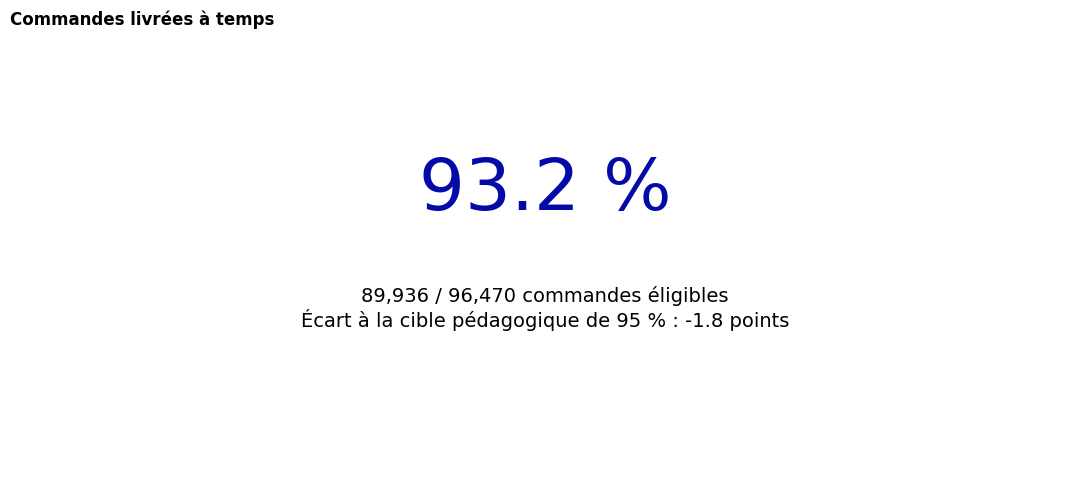

In [6]:
ID_GRAPHIQUE = '06_01'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.axis('off');ax.text(.5,.62,f'{taux:.1f} %',ha='center',fontsize=52,color=palette[0],transform=ax.transAxes);ax.text(.5,.35,f'{a_temps:,} / {n:,} commandes éligibles\nÉcart à la cible pédagogique de 95 % : {taux-OBJECTIF:+.1f} points',ha='center',fontsize=14,transform=ax.transAxes)
terminer(ax,'Commandes livrées à temps')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

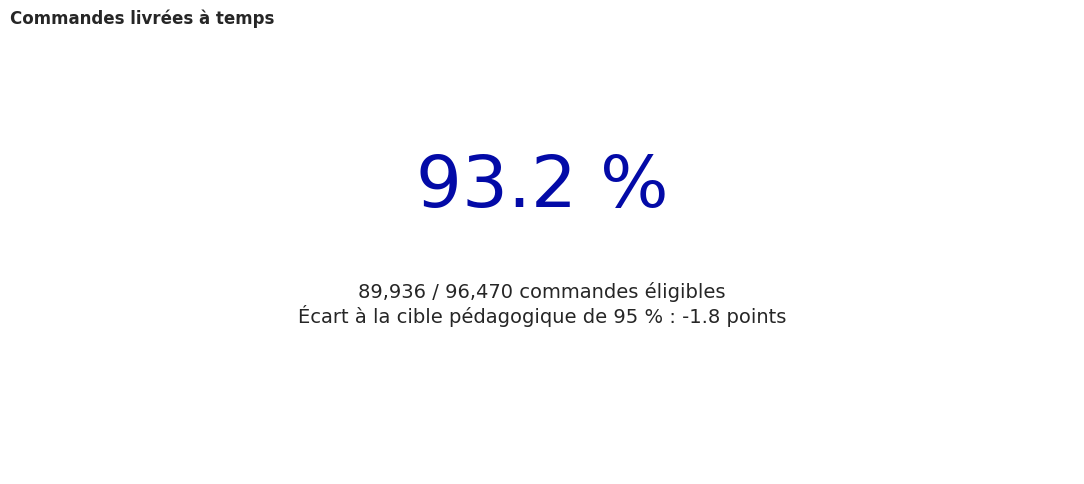

In [7]:
ID_GRAPHIQUE = '06_01'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
ax.axis('off');ax.text(.5,.62,f'{taux:.1f} %',ha='center',fontsize=52,color=sns.color_palette(palette)[0],transform=ax.transAxes);ax.text(.5,.35,f'{a_temps:,} / {n:,} commandes éligibles\nÉcart à la cible pédagogique de 95 % : {taux-OBJECTIF:+.1f} points',ha='center',fontsize=14,transform=ax.transAxes)
terminer(ax,'Commandes livrées à temps')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

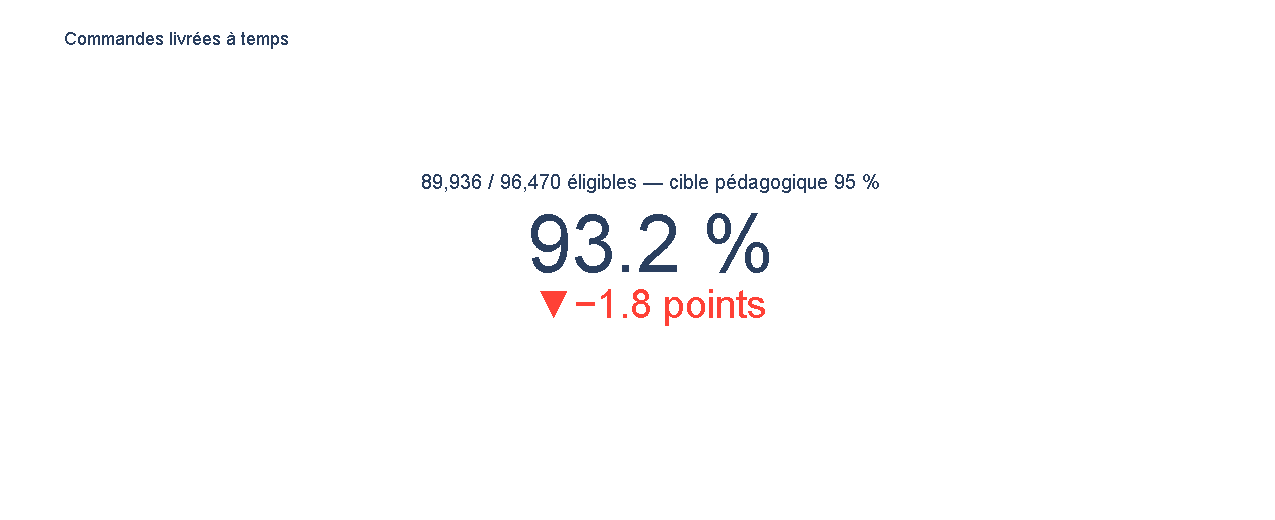

In [8]:
ID_GRAPHIQUE = '06_01'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure(go.Indicator(mode='number+delta',value=taux,number={'suffix':' %'},delta={'reference':OBJECTIF,'relative':False,'suffix':' points'},title={'text':f'{a_temps:,} / {n:,} éligibles — cible pédagogique 95 %'}))
montrer_plotly(fig,'Commandes livrées à temps')

**À lire dans les trois variantes :** Afficher le taux de commandes livrées au plus tard le jour estimé. Variables : taux Q et cible pédagogique Q. Le dénominateur ne comprend que les commandes livrées avec une date estimée.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>2 — Bullet chart</div></b>

Comparer le taux de livraison à une cible de 95 %. Variables : réalisé Q + cible Q. Les plages 0–80, 80–95, 95–100 % sont des seuils d’exercice, non des règles métier attestées.

In [9]:
eligibles=donnees.loc[donnees.status.eq('delivered') & donnees.retard_jours.notna()].copy()
n=len(eligibles);a_temps=int(eligibles.retard_jours.le(0).sum());taux=100*a_temps/n
OBJECTIF=95.0  # Hypothèse pédagogique, pas un engagement contractuel observé.
print(f'Livrées avec date estimée : {n:,} ; à temps : {a_temps:,} ; taux : {taux:.2f}%')

Livrées avec date estimée : 96,470 ; à temps : 89,936 ; taux : 93.23%


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

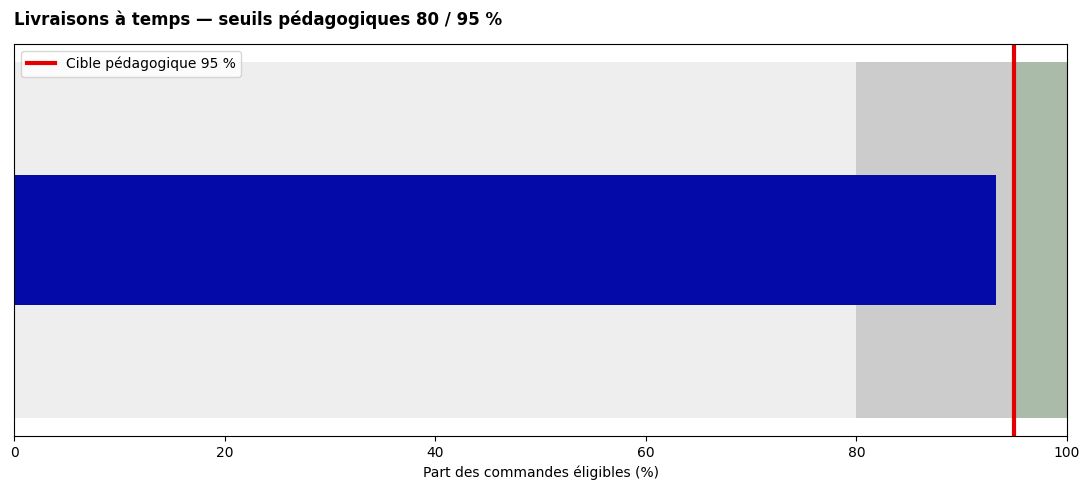

In [10]:
ID_GRAPHIQUE = '06_02'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes(False)
for left,width,c in [(0,80,'#eeeeee'),(80,15,'#cccccc'),(95,5,'#aabbaa')]:ax.barh([0],[width],left=left,height=.6,color=c)
ax.barh([0],[taux],height=.22,color=palette[0]);ax.axvline(OBJECTIF,color=palette[1],linewidth=3,label='Cible pédagogique 95 %');ax.set(xlim=(0,100),yticks=[]);ax.legend()
terminer(ax,'Livraisons à temps — seuils pédagogiques 80 / 95 %','Part des commandes éligibles (%)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

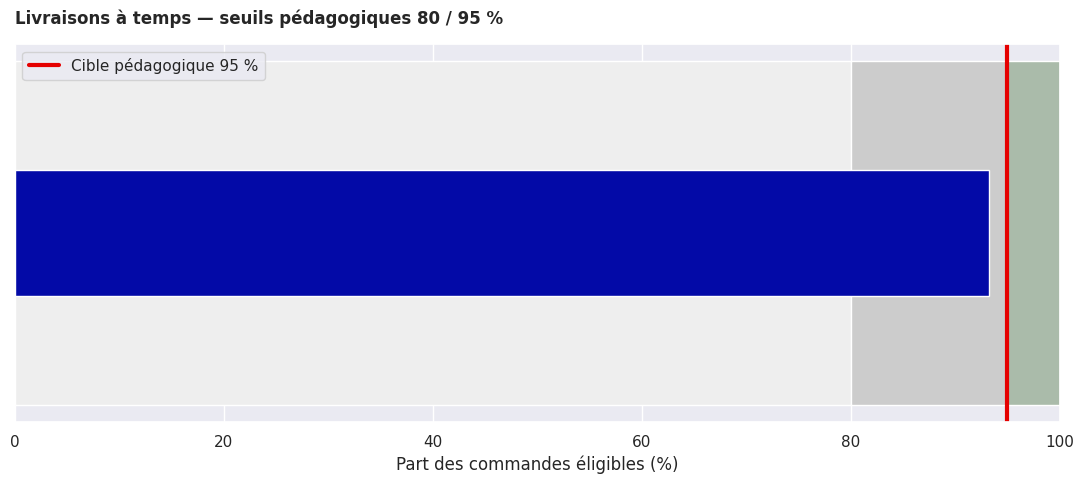

In [11]:
ID_GRAPHIQUE = '06_02'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
for left,width,c in [(0,80,'#eeeeee'),(80,15,'#cccccc'),(95,5,'#aabbaa')]:ax.barh([0],[width],left=left,height=.6,color=c)
ax.barh([0],[taux],height=.22,color=palette[0]);ax.axvline(OBJECTIF,color=palette[1],linewidth=3,label='Cible pédagogique 95 %');ax.set(xlim=(0,100),yticks=[]);ax.legend()
terminer(ax,'Livraisons à temps — seuils pédagogiques 80 / 95 %','Part des commandes éligibles (%)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

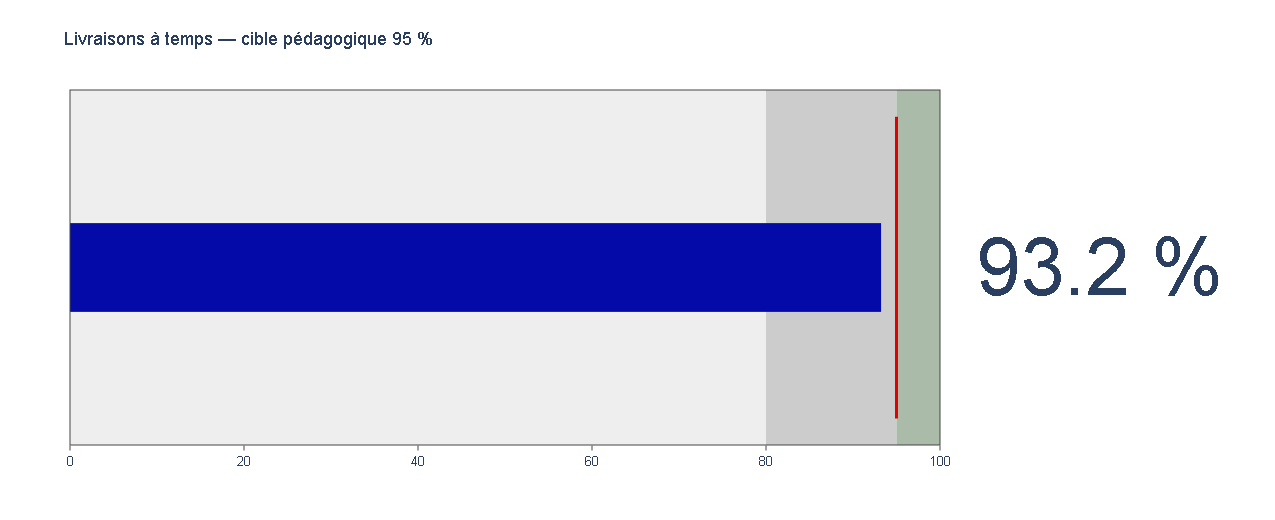

In [12]:
ID_GRAPHIQUE = '06_02'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure(go.Indicator(mode='gauge+number',value=taux,number={'suffix':' %'},gauge={'shape':'bullet','axis':{'range':[0,100]},'bar':{'color':palette[0]},'steps':[{'range':[0,80],'color':'#eeeeee'},{'range':[80,95],'color':'#cccccc'},{'range':[95,100],'color':'#aabbaa'}],'threshold':{'line':{'color':palette[1],'width':3},'value':OBJECTIF}}))
montrer_plotly(fig,'Livraisons à temps — cible pédagogique 95 %')

**À lire dans les trois variantes :** Comparer le taux de livraison à une cible de 95 %. Variables : réalisé Q + cible Q. Les plages 0–80, 80–95, 95–100 % sont des seuils d’exercice, non des règles métier attestées.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>3 — Barres divergentes</div></b>

Comparer les écarts à la cible pédagogique par état pour les dix états les plus représentés. Variables : état C + écart signé Q, exprimé en points de pourcentage.

In [13]:
eligibles=donnees.loc[donnees.status.eq('delivered') & donnees.retard_jours.notna()].copy()
n=len(eligibles);a_temps=int(eligibles.retard_jours.le(0).sum());taux=100*a_temps/n
OBJECTIF=95.0  # Hypothèse pédagogique, pas un engagement contractuel observé.
print(f'Livrées avec date estimée : {n:,} ; à temps : {a_temps:,} ; taux : {taux:.2f}%')

a=eligibles.groupby('state').agg(n=('order_id','size'),taux=('retard_jours',lambda x:100*x.le(0).mean())).nlargest(10,'n')
a['ecart']=a.taux-OBJECTIF
a=a.sort_values('ecart').reset_index();display(a)

Livrées avec date estimée : 96,470 ; à temps : 89,936 ; taux : 93.23%


,state,n,taux,ecart
0,BA,3256,87.837838,-7.162162
1,RJ,12350,87.894737,-7.105263
2,ES,1995,89.273183,-5.726817
3,SC,3546,91.793570,-3.206430
4,GO,1957,93.459377,-1.540623
5,RS,5344,93.918413,-1.081587
6,DF,2080,94.326923,-0.673077
7,MG,11354,95.428924,0.428924
8,SP,40494,95.505507,0.505507
9,PR,4923,95.957749,0.957749


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

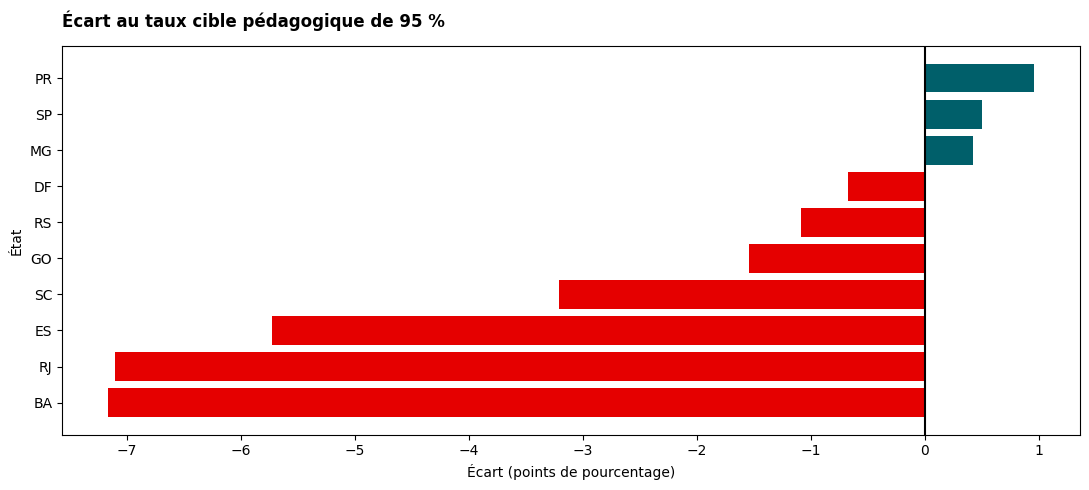

In [14]:
ID_GRAPHIQUE = '06_03'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.barh(a.state,a.ecart,color=np.where(a.ecart.ge(0),palette[3],palette[1]));ax.axvline(0,color='black')
terminer(ax,'Écart au taux cible pédagogique de 95 %','Écart (points de pourcentage)','État')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn</div></b>

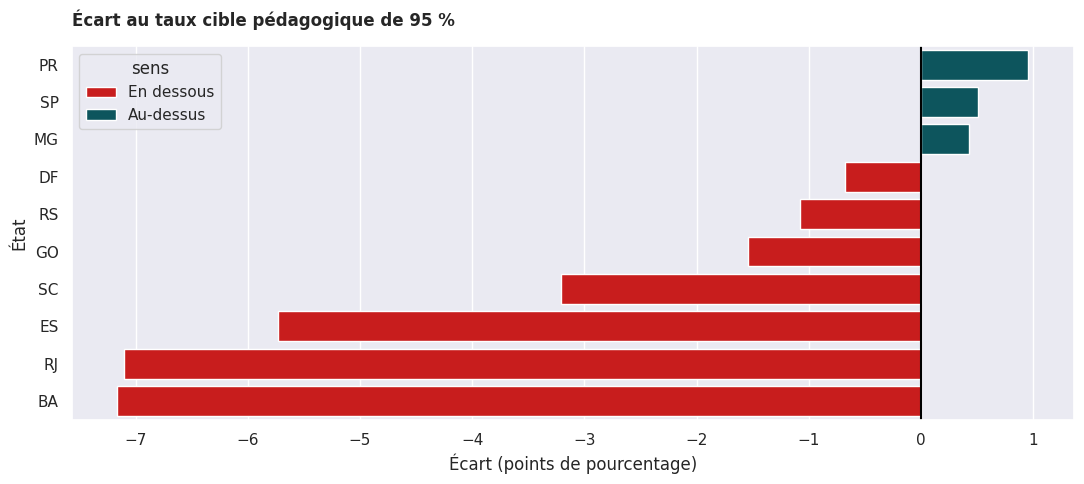

In [15]:
ID_GRAPHIQUE = '06_03'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
a['sens']=np.where(a.ecart.ge(0),'Au-dessus','En dessous')
sns.barplot(data=a,x='ecart',y='state',hue='sens',dodge=False,errorbar=None,palette={'Au-dessus':palette[3],'En dessous':palette[1]},ax=ax);ax.axvline(0,color='black')
ax.invert_yaxis()
terminer(ax,'Écart au taux cible pédagogique de 95 %','Écart (points de pourcentage)','État')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

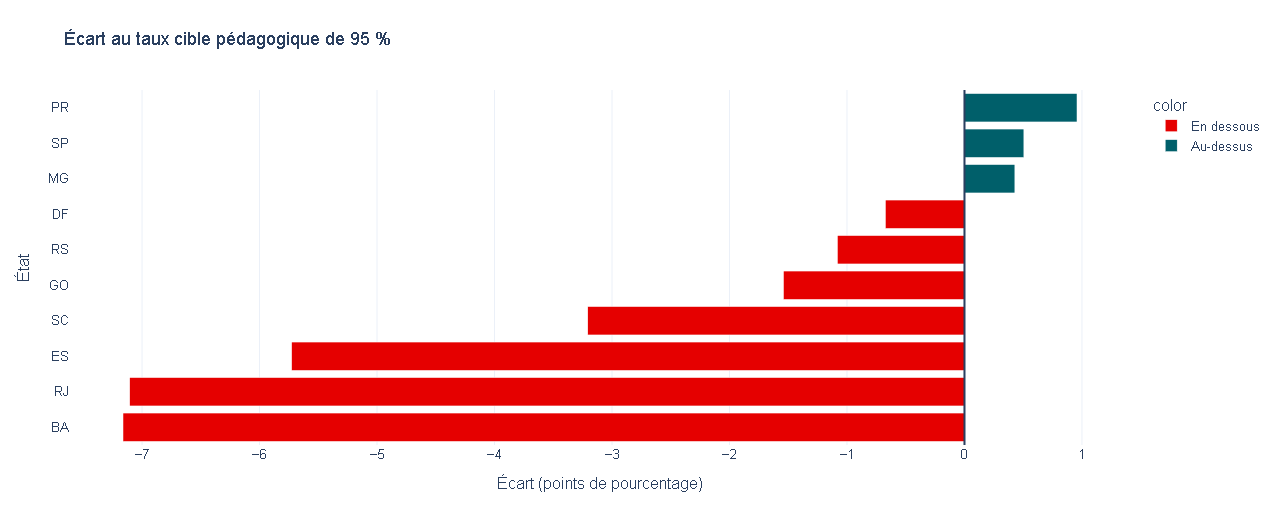

In [16]:
ID_GRAPHIQUE = '06_03'
BIBLIOTHEQUE = 'plotly'
fig=px.bar(a,x='ecart',y='state',orientation='h',color=np.where(a.ecart.ge(0),'Au-dessus','En dessous'),color_discrete_map={'Au-dessus':palette[3],'En dessous':palette[1]},hover_data=['n','taux'],labels={'ecart':'Écart (points de pourcentage)','state':'État'})
fig.add_vline(x=0);montrer_plotly(fig,'Écart au taux cible pédagogique de 95 %')

**À lire dans les trois variantes :** Comparer les écarts à la cible pédagogique par état pour les dix états les plus représentés. Variables : état C + écart signé Q, exprimé en points de pourcentage.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>4 — Cascade</div></b>

Réconcilier le montant des articles et des frais de port des commandes livrées ayant des articles. Variables : composante ordonnée O + montant Q. Ce total n’est ni une marge ni un total de paiements.

In [17]:
d=donnees.loc[donnees.status.eq('delivered') & donnees.total_commande.notna()]
articles=float(d.montant_articles.sum());port=float(d.frais_port.sum());total=articles+port
etapes=['Articles','Frais de port','Total'];valeurs=[articles,port,total]
assert np.isclose(total,d.total_commande.sum())
display(pd.DataFrame({'étape':etapes,'montant_source':valeurs}))

,étape,montant_source
0,Articles,13221498.11
1,Frais de port,2198275.64
2,Total,15419773.75


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

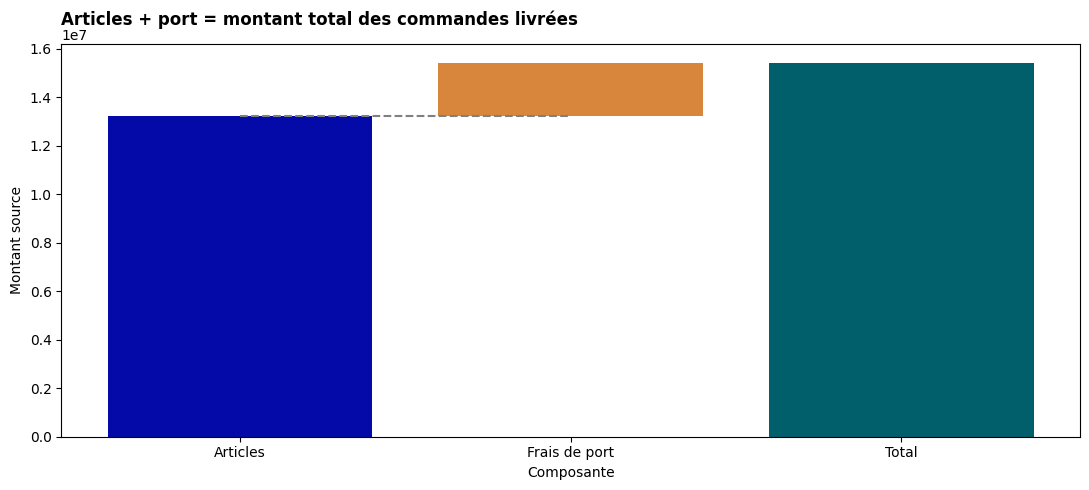

In [18]:
ID_GRAPHIQUE = '06_04'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.bar(etapes,[articles,port,total],bottom=[0,articles,0],color=[palette[0],palette[2],palette[3]]);ax.plot([0,1],[articles,articles],color='gray',ls='--')
terminer(ax,'Articles + port = montant total des commandes livrées','Composante','Montant source')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

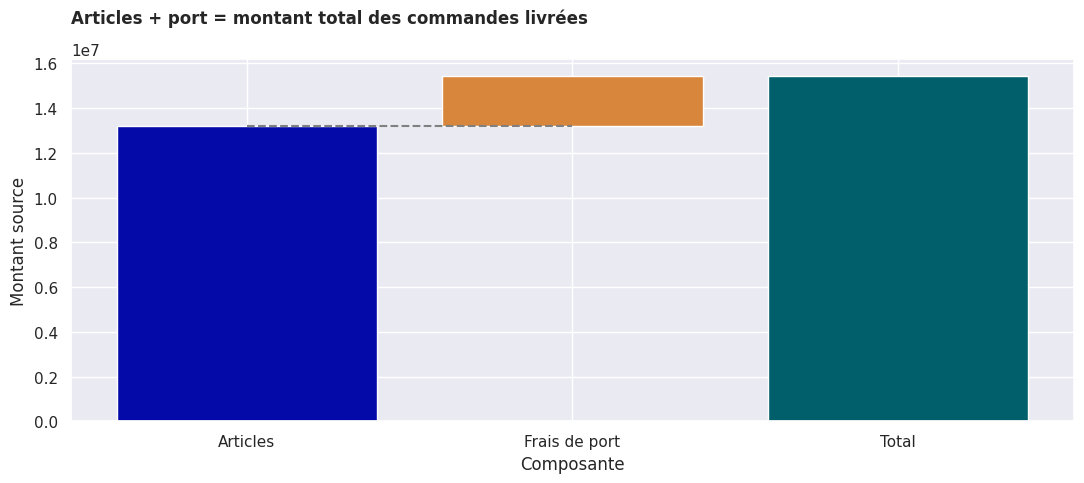

In [19]:
ID_GRAPHIQUE = '06_04'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
ax.bar(etapes,[articles,port,total],bottom=[0,articles,0],color=sns.color_palette([palette[0],palette[2],palette[3]]));ax.plot([0,1],[articles,articles],color='gray',ls='--')
terminer(ax,'Articles + port = montant total des commandes livrées','Composante','Montant source')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

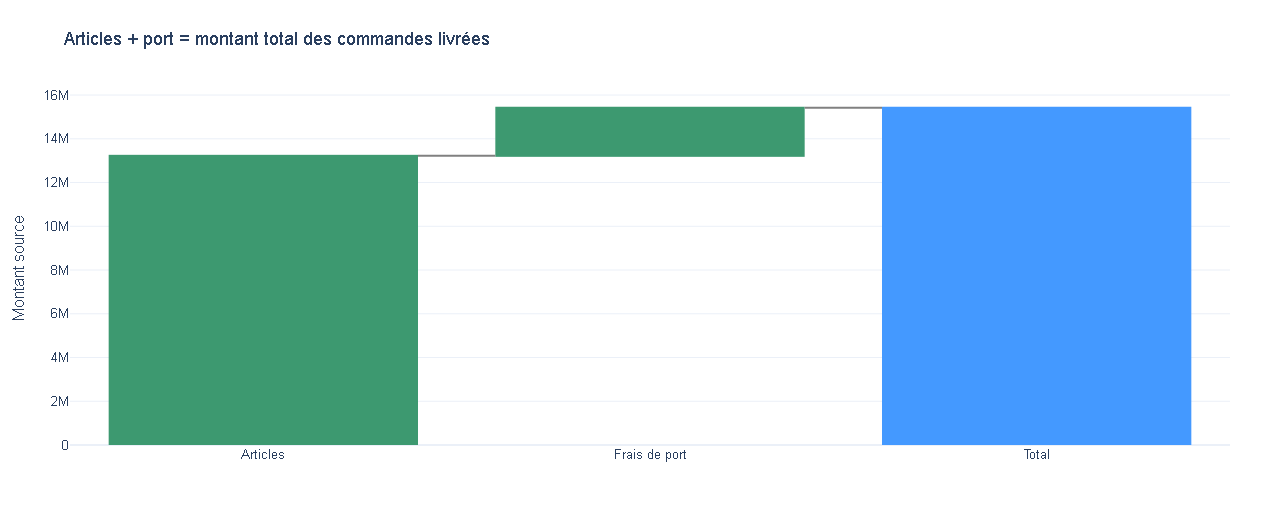

In [20]:
ID_GRAPHIQUE = '06_04'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure(go.Waterfall(x=etapes,y=[articles,port,0],measure=['relative','relative','total'],connector={'line':{'color':'gray'}}))
fig.update_layout(yaxis_title='Montant source');montrer_plotly(fig,'Articles + port = montant total des commandes livrées')

**À lire dans les trois variantes :** Réconcilier le montant des articles et des frais de port des commandes livrées ayant des articles. Variables : composante ordonnée O + montant Q. Ce total n’est ni une marge ni un total de paiements.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>5 — Pareto</div></b>

Prioriser les états contributeurs aux livraisons en retard. Variables : état C + effectif Q ; cumul dérivé. Il s’agit de contributions de volume, pas d’un classement des taux de retard.

In [21]:
eligibles=donnees.loc[donnees.status.eq('delivered') & donnees.retard_jours.notna()].copy()
n=len(eligibles);a_temps=int(eligibles.retard_jours.le(0).sum());taux=100*a_temps/n
OBJECTIF=95.0  # Hypothèse pédagogique, pas un engagement contractuel observé.
print(f'Livrées avec date estimée : {n:,} ; à temps : {a_temps:,} ; taux : {taux:.2f}%')

a=eligibles.loc[eligibles.retard_jours.gt(0),'state'].value_counts().rename_axis('etat').reset_index(name='n')
a['cumul']=100*a.n.cumsum()/a.n.sum()
assert np.isclose(a.cumul.iloc[-1],100)
display(a)

Livrées avec date estimée : 96,470 ; à temps : 89,936 ; taux : 93.23%


,etat,n,cumul
0,SP,1820,27.854301
1,RJ,1495,50.734619
2,MG,519,58.677686
3,BA,396,64.738292
4,RS,325,69.712274
5,SC,291,74.165901
6,ES,214,77.441077
7,PR,199,80.486685
8,CE,176,83.180288
9,PE,153,85.521886


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

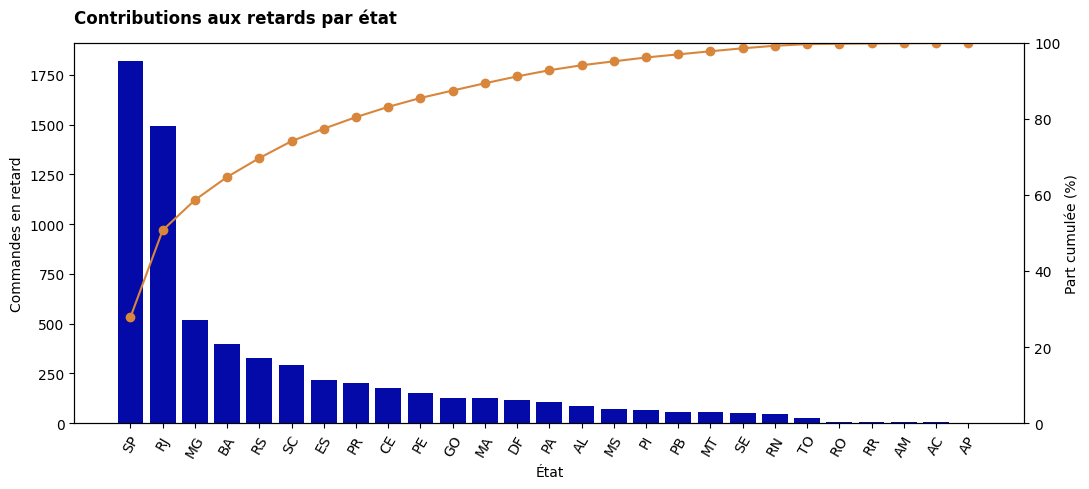

In [22]:
ID_GRAPHIQUE = '06_05'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.bar(a.etat,a.n,color=palette[0]);ax2=ax.twinx();ax2.plot(a.etat,a.cumul,color=palette[2],marker='o');ax2.set_ylim(0,100);ax2.set_ylabel('Part cumulée (%)');ax.tick_params(axis='x',rotation=60)
terminer(ax,'Contributions aux retards par état','État','Commandes en retard')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

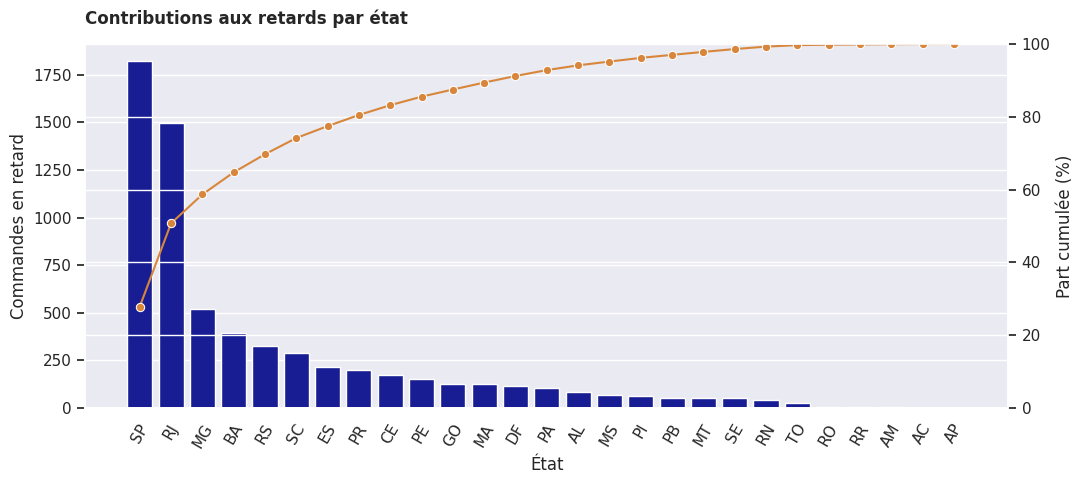

In [23]:
ID_GRAPHIQUE = '06_05'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
sns.barplot(data=a,x='etat',y='n',color=palette[0],errorbar=None,ax=ax);ax2=ax.twinx();sns.lineplot(x=np.arange(len(a)),y=a.cumul,estimator=None,color=palette[2],marker='o',ax=ax2);ax2.set_ylim(0,100);ax2.set_ylabel('Part cumulée (%)');ax.tick_params(axis='x',rotation=60)
terminer(ax,'Contributions aux retards par état','État','Commandes en retard')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

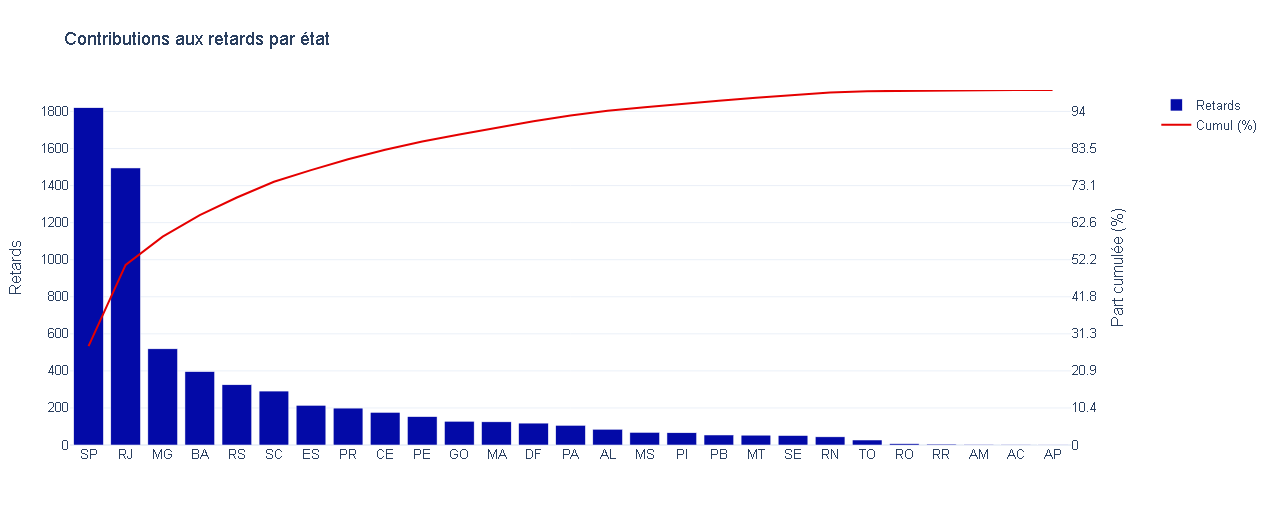

In [24]:
ID_GRAPHIQUE = '06_05'
BIBLIOTHEQUE = 'plotly'
fig=make_subplots(specs=[[{'secondary_y':True}]])
fig.add_trace(go.Bar(x=a.etat,y=a.n,name='Retards'),secondary_y=False);fig.add_trace(go.Scatter(x=a.etat,y=a.cumul,name='Cumul (%)'),secondary_y=True);fig.update_yaxes(title_text='Retards',secondary_y=False);fig.update_yaxes(title_text='Part cumulée (%)',range=[0,100],secondary_y=True)
montrer_plotly(fig,'Contributions aux retards par état')

**À lire dans les trois variantes :** Prioriser les états contributeurs aux livraisons en retard. Variables : état C + effectif Q ; cumul dérivé. Il s’agit de contributions de volume, pas d’un classement des taux de retard.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>6 — Entonnoir</div></b>

Compter les commandes avec jalons chronologiques documentés et successifs : achat, approbation, remise transporteur, livraison. Variables : étape O + effectif Q. Chaque masque contient le précédent ; une absence peut venir d’un jalon manquant, pas seulement d’un abandon.

In [25]:
achat=donnees.purchase_timestamp.notna()
approuve=achat & donnees.approved_at.notna() & donnees.approved_at.ge(donnees.purchase_timestamp)
expedie=approuve & donnees.delivered_carrier.notna() & donnees.delivered_carrier.ge(donnees.approved_at)
livre=expedie & donnees.delivered_customer.notna() & donnees.delivered_customer.ge(donnees.delivered_carrier)
a=pd.DataFrame({'etape':['Achat renseigné','Approbation cohérente','Expédition cohérente','Livraison cohérente'],'n':[int(m.sum()) for m in [achat,approuve,expedie,livre]]})
a['part_initiale']=100*a.n/a.n.iloc[0]
assert a.n.is_monotonic_decreasing
display(a)

,etape,n,part_initiale
0,Achat renseigné,99441,100.000000
1,Approbation cohérente,99281,99.839101
2,Expédition cohérente,96285,96.826259
3,Livraison cohérente,95088,95.622530


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

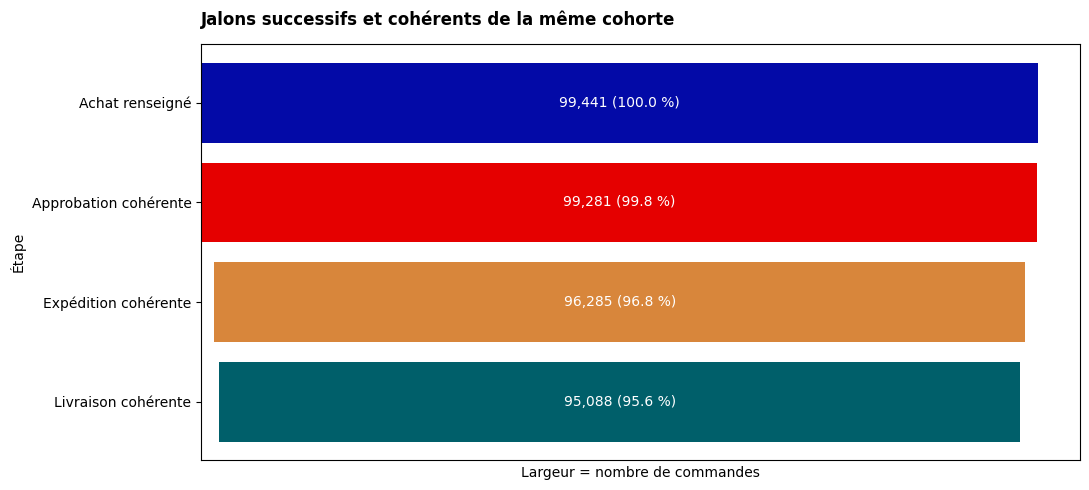

In [26]:
ID_GRAPHIQUE = '06_06'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.barh(a.etape,a.n,left=-a.n/2,color=palette[:4]);ax.invert_yaxis();ax.set_xticks([])
for j,r in enumerate(a.itertuples()):ax.text(0,j,f'{r.n:,} ({r.part_initiale:.1f} %)',ha='center',va='center',color='white')
terminer(ax,'Jalons successifs et cohérents de la même cohorte','Largeur = nombre de commandes','Étape')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

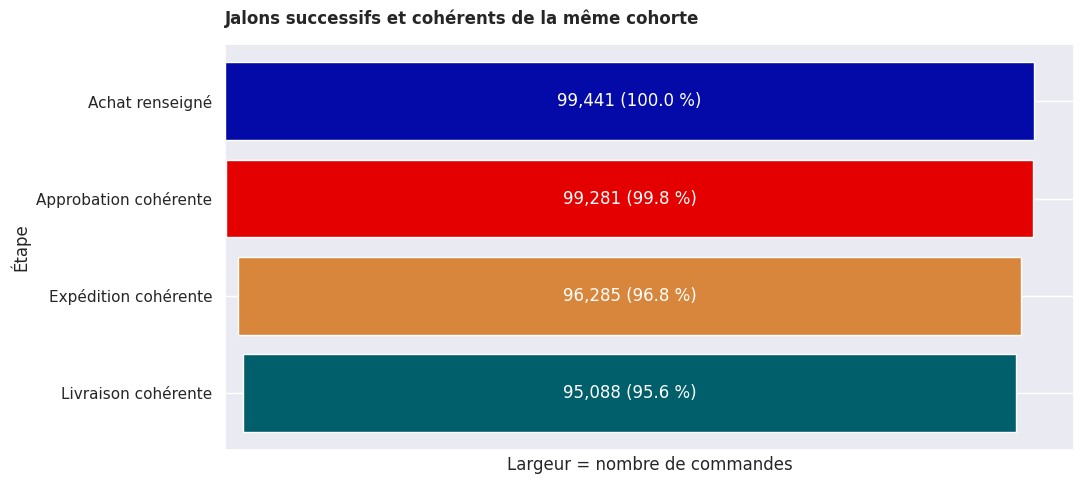

In [27]:
ID_GRAPHIQUE = '06_06'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
ax.barh(a.etape,a.n,left=-a.n/2,color=sns.color_palette(palette[:4]));ax.invert_yaxis();ax.set_xticks([])
for j,r in enumerate(a.itertuples()):ax.text(0,j,f'{r.n:,} ({r.part_initiale:.1f} %)',ha='center',va='center',color='white')
terminer(ax,'Jalons successifs et cohérents de la même cohorte','Largeur = nombre de commandes','Étape')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

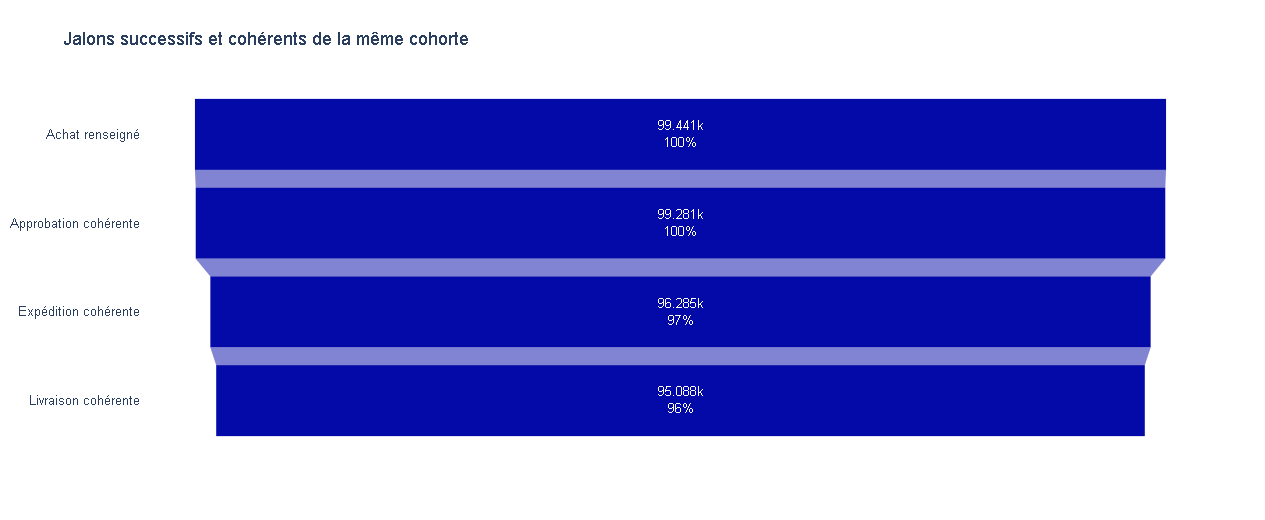

In [28]:
ID_GRAPHIQUE = '06_06'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure(go.Funnel(y=a.etape,x=a.n,textinfo='value+percent initial'))
montrer_plotly(fig,'Jalons successifs et cohérents de la même cohorte')

**À lire dans les trois variantes :** Compter les commandes avec jalons chronologiques documentés et successifs : achat, approbation, remise transporteur, livraison. Variables : étape O + effectif Q. Chaque masque contient le précédent ; une absence peut venir d’un jalon manquant, pas seulement d’un abandon.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Synthèse et exercices</div></b>

1. Reformuler la question métier de chacun des six graphiques.
2. Modifier un filtre ou une période et expliquer son effet sur le dénominateur.
3. Choisir une variante pour un rapport imprimé et une pour un tableau de bord interactif.
4. Vérifier l’unité, l’effectif, les valeurs manquantes et le sens des encodages.

**Limites :** Les tables locales constituent la source ; aucune base de démonstration ne les remplace. Les articles sont agrégés au niveau commande avant jointure. Les commandes sans article ou sans livraison restent manquantes pour les mesures concernées. Les délais sont recalculés : les colonnes de durée préexistantes ne sont pas présumées documentées. L’unité monétaire BRL est une hypothèse de contexte ; les graphiques indiquent « montant source ».